# Хлебозавод: что журнал событий говорит о линииЭта тетрадь отвечает на один вопрос владельца пекарни:> **«Линия не успевает. Куда вкладывать деньги?»**Мы не будем спрашивать мастеров и не будем гадать. Всё, что нужно, уже записано:каждая партия теста, проходя по линии, оставляет отметки «начал месить», «закончил месить»,«поставил на расстойку» и так далее. Этот поток отметок называется **журналом событий**(event log), а дисциплина, которая из него восстанавливает реальный процесс, —**process mining**.Что будет дальше:| Раздел | Что делаем | Что получаем ||---|---|---|| (a) | Достаём журнал из InfluxDB | таблица «партия — действие — время» || (b) | Discovery | карта процесса: как линия работает **на самом деле** || (c) | Performance | где уходит время → **узкое место** || (d) | Параметры | таблица чисел для симулятора JaamSim || (e) | Грязные данные | что будет, если журнал неполный |Разделы (a)–(d) — это «поставить диагноз». Лечение (что будет, если купить вторую печь)считается уже в JaamSim, файл `jaamsim/BakeryLine.cfg`, и именно раздел (d) даёт ему числа.

---## (a) Журнал событий: достаём и приводим в порядокЛиния пишет события в MQTT, Telegraf кладёт их в InfluxDB в измерение `batch_events`.Одна строка = одно событие. Теги: `case_id` (номер партии), `activity` (что произошло),`station` (на какой станции), `mode` (какой прогон). Поля: `ts`, `seq`, `queue_len`, `wip`.**Три ловушки, каждая из которых убивает анализ молча.**1. **Два разных времени.** У точки в InfluxDB есть время *приёма* (`_time`) — когда запись   долетела до базы. И есть поле `ts` — время *процесса*, то, что показывали часы в цеху.   Прогон был ускорен в 200 раз, поэтому по `_time` все длительности окажутся в 200 раз   короче. Майнинг обязан брать `ts`.2. **Одновременные события.** «Замес закончен» и «поставлено на расстойку» происходят в одну   и ту же секунду — так устроен процесс. По времени их не упорядочить, порядок внутри партии   получится случайный. Для этого есть поле `seq` — счётчик, который разводит ничьи.3. **Чужие данные в том же измерении.** Там же лежат две партии от старого smoke-теста   (`smoke-0001`, `smoke-0002`). Фильтр по префиксу `batch-` обязателен.Вся эта водопроводная работа уже написана в `mining.py` — импортируем оттуда, чтобы тетрадьи скрипт не разъехались.

In [1]:
import os, sys, math
import pandas as pd
import pm4py
from IPython.display import Image, display

sys.path.insert(0, os.path.expanduser("~/course/bakery"))
import mining                          # тот же код, что запускает агент и runbook

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

OUT = "/tmp/bakery-mining"
os.makedirs(OUT, exist_ok=True)

MODE  = "normal"        # какой прогон анализируем
RANGE = "-24h"          # окно поиска в InfluxDB

# Какие партии брать. В InfluxDB лежит несколько прогонов, и они не должны
# смешиваться:
#   "batch-00" — эталонный датасет, на нём построена вся эта тетрадь
#   "batch-01" — «грязный» прогон, раздел (e)
#   "batch-02" — ваш свежий прогон из шага 1 runbook'а
#   "batch-"   — ВСЁ сразу; почти всегда не то, что нужно
CASE_PREFIX = "batch-00"

df = mining.load_event_log(time_range=RANGE, mode=MODE, case_prefix=CASE_PREFIX)
df[["case:concept:name", "concept:name", "org:resource", "time:timestamp", "seq"]].head(10)



  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




,case:concept:name,concept:name,org:resource,time:timestamp,seq
0,batch-0001,MixingStarted,mixer-1,2026-08-07 12:40:38+00:00,1.0
1,batch-0001,MixingDone,mixer-1,2026-08-07 12:49:00+00:00,2.0
2,batch-0001,ProofingStarted,proofer-1,2026-08-07 12:49:00+00:00,3.0
3,batch-0001,ProofingDone,proofer-1,2026-08-07 13:26:59+00:00,12.0
4,batch-0001,BakingStarted,oven-1,2026-08-07 13:26:59+00:00,13.0
5,batch-0001,BakingDone,oven-1,2026-08-07 13:50:15+00:00,21.0
6,batch-0001,PackingStarted,packer-1,2026-08-07 13:50:15+00:00,22.0
7,batch-0001,PackingDone,packer-1,2026-08-07 13:54:15+00:00,27.0
8,batch-0002,MixingStarted,mixer-1,2026-08-07 12:53:00+00:00,4.0
9,batch-0002,MixingDone,mixer-1,2026-08-07 13:02:22+00:00,5.0


Три колонки в этой таблице — это весь контракт process mining, ничего больше не нужно:* `case:concept:name` — **экземпляр процесса**. Здесь это партия теста.* `concept:name` — **действие**.* `time:timestamp` — **когда**.Колонка `org:resource` (станция) не обязательна, но полезна: по ней мы потом разложим времяпо оборудованию.Прежде чем что-либо интерпретировать, надо назвать размер выборки. Журнал из четырёх партийне подтверждает ничего, и сказать об этом — часть ответа.

In [2]:
shape = mining.log_shape(df)
for k, v in shape.items():
    print(f"{k:>22}: {v}")

                events: 160
                 cases: 20
            activities: 8
            first_case: batch-0001
             last_case: batch-0020
   events_per_case_min: 8
   events_per_case_max: 8
  events_per_case_mean: 8.0
        complete_cases: 20


20 партий, у каждой ровно 8 событий, ни одной оборванной. Для учебного примера этого хватает;для решения о покупке печи на реальном заводе — нет, там нужны недели данных. Помните об этом,когда в разделе (d) появятся красивые числа с двумя знаками после запятой.

---## (b) Discovery: как линия работает на самом делеDiscovery — это восстановление модели процесса из журнала. Мы не рисуем схему «как должнобыть» и не сверяемся с регламентом: алгоритм смотрит только на последовательности событий.Два разных взгляда:* **DFG** (directly-follows graph, граф непосредственного следования) — «после действия A  сколько раз сразу шло действие B». Это самая честная и самая читаемая картинка: никакой  алгоритм ничего не додумал, только пересчитал переходы.* **Сеть Петри** через **inductive miner** — уже настоящая модель процесса, с логикой ветвлений  и параллелизма. Inductive miner ценен тем, что выдаёт заведомо корректную модель (sound):  такую, в которой процесс не может застрять.

In [3]:
log = pm4py.format_dataframe(df.copy(), case_id="case:concept:name",
                             activity_key="concept:name",
                             timestamp_key="time:timestamp")

dfg, start_acts, end_acts = pm4py.discover_dfg(log)

print(f"рёбер в графе: {len(dfg)}")
print(f"стартовые действия: {dict(start_acts)}")
print(f"конечные действия:  {dict(end_acts)}")
print()
for (a, b), n in sorted(dfg.items(), key=lambda kv: -kv[1]):
    print(f"{n:>4}x  {a} -> {b}")

рёбер в графе: 7
стартовые действия: {'MixingStarted': 20}
конечные действия:  {'PackingDone': 20}

  20x  BakingDone -> PackingStarted
  20x  BakingStarted -> BakingDone
  20x  MixingDone -> ProofingStarted
  20x  MixingStarted -> MixingDone
  20x  PackingStarted -> PackingDone
  20x  ProofingDone -> BakingStarted
  20x  ProofingStarted -> ProofingDone


**7 рёбер, одно стартовое действие, одно конечное, у каждого перехода ровно 20 повторений.**Это идеальная картина: все 20 партий прошли по одному и тому же маршруту, ни одна не вернуласьна переделку, ни одна не начала с середины. Такой процесс называют *однопоточным* — у негоодин вариант (variant). Запомните, как это выглядит: в разделе (e) мы посмотрим на тот жепроцесс по неполному журналу, и там будет 11 рёбер и три разных начала.

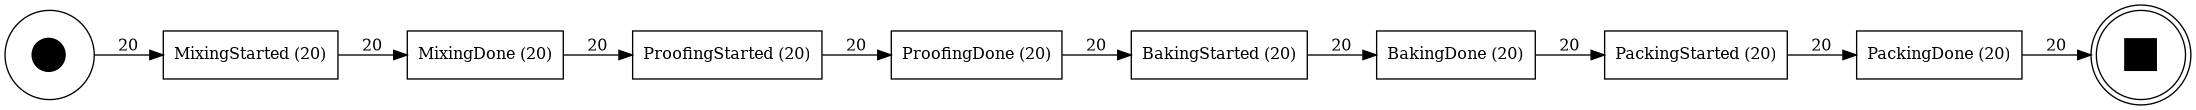

In [4]:
dfg_png = f"{OUT}/process_map_{MODE}.png"
pm4py.save_vis_dfg(dfg, start_acts, end_acts, dfg_png)
display(Image(dfg_png))

Карта процесса. Читается сверху вниз, числа на стрелках — сколько партий по ним прошло.Это и есть «как линия работает на самом деле», восстановленное из отметок, а не из регламента.Теперь сеть Петри — модель с логикой, а не просто пересчёт переходов.

сеть Петри: 9 мест, 8 переходов, 16 дуг
fitness (token-based replay): 1.0000


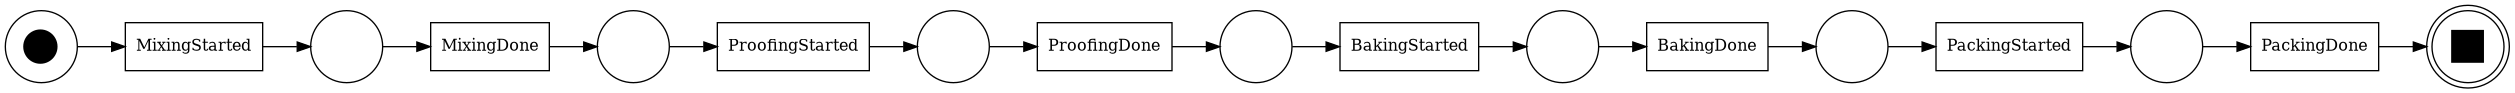

In [5]:
net, im, fm = pm4py.discover_petri_net_inductive(log)
print(f"сеть Петри: {len(net.places)} мест, {len(net.transitions)} переходов, {len(net.arcs)} дуг")

fit = pm4py.fitness_token_based_replay(log, net, im, fm)
print(f"fitness (token-based replay): {fit['log_fitness']:.4f}")

net_png = f"{OUT}/petri_net_{MODE}.png"
pm4py.save_vis_petri_net(net, im, fm, net_png)
display(Image(net_png))

**Fitness = 1.0** означает, что модель воспроизводит каждую партию из журнала без единогорасхождения. Для строго последовательного процесса это ожидаемо и потому неинтересно —но это хорошая проверка, что мы ничего не сломали при загрузке. Если бы `seq` не развёлодновременные события, порядок внутри партий поплыл бы, и fitness просел бы сразу.

---## (c) Performance: где уходит времяКарта показывает *что* происходит. Деньги — во *сколько это стоит времени*.Ключевое различие, ради которого весь этот анализ и затевается:* **service time** (время обслуживания) — партия внутри станции, оборудование работает.  Это `XxxStarted -> XxxDone`.* **waiting time** (время ожидания) — партия готова, но станция занята. Это  `ПредыдущаяDone -> СледующаяStarted`.Первое сокращается покупкой более быстрого оборудования. Второе — только расшивкой узкогоместа. Различать их обязательно, иначе легко купить быструю печь там, где надо было купитьвторую.

In [6]:
perf = mining.performance_dfg(df)
perf[["edge", "mean_min", "median_min"]].round(1)

,edge,mean_min,median_min
0,ProofingDone -> BakingStarted,106.5,93.2
1,ProofingStarted -> ProofingDone,39.1,39.0
2,BakingStarted -> BakingDone,25.7,24.9
3,MixingStarted -> MixingDone,8.1,7.8
4,MixingDone -> ProofingStarted,5.1,3.8
5,PackingStarted -> PackingDone,5.0,5.0
6,BakingDone -> PackingStarted,0.0,0.0


Верхняя строка — `ProofingDone -> BakingStarted`, **106.5 минуты**. Это не работа. Эторасстоявшееся тесто, которое стоит и ждёт, пока освободится печь.Разложим то же самое по станциям — так, как это видит владелец.

In [7]:
sw = mining.service_and_waiting(df)
view = sw[["service_mean", "wait_mean", "total_mean"]].round(1)
view["share_%"] = (100 * sw["total_mean"] / sw["total_mean"].sum()).round(1)
view

,service_mean,wait_mean,total_mean,share_%
station,,,,
mixer-1,8.1,NaN,8.1,4.3
proofer-1,39.1,5.1,44.2,23.3
oven-1,25.7,106.5,132.2,69.8
packer-1,5.0,0.0,5.0,2.6


Смотрим на строку `oven-1`: **работа 25.7 мин, ожидание 106.5 мин.** Печь тратит на партию26 минут, а партия проводит возле печи 132 минуты — то есть **на каждую минуту выпечкиприходится 4 минуты ожидания**. И это 70% всего времени изготовления партии.У `mixer-1` в колонке ожидания стоит `NaN`, и это не описка. Это **«не измерено»**: журналначинается с события `MixingStarted`, время от «партию поставили в план» до «начали месить»просто не записывается. С настоящими журналами так бывает постоянно, и правильная реакция —сказать об этом вслух, а не молча подставить ноль и потом объяснять, почему сумма не сходится.

In [8]:
station, wait = mining.bottleneck(df)
print(f"УЗКОЕ МЕСТО: {station}")
print(f"  среднее ожидание перед началом выпечки: {wait:.1f} мин")
print(f"  сама выпечка занимает:                  {sw.loc[station, 'service_mean']:.1f} мин")
print()

# Длину очереди линия пишет в каждое событие, так что узкое место видно
# и вообще без process mining — это полезно показать бизнесу.
print("Очередь по станциям (из поля queue_len, без всякого майнинга):")
for st in mining.ROUTE:
    sub = df[df["org:resource"] == st]
    print(f"  {st:<10} max={int(sub['queue_len'].max()):>2}   mean={sub['queue_len'].mean():.2f}")

УЗКОЕ МЕСТО: oven-1
  среднее ожидание перед началом выпечки: 106.5 мин
  сама выпечка занимает:                  25.7 мин

Очередь по станциям (из поля queue_len, без всякого майнинга):
  mixer-1    max= 0   mean=0.00
  proofer-1  max= 2   mean=0.45
  oven-1     max= 9   mean=4.17
  packer-1   max= 0   mean=0.00


Перед печью скапливалось **до 9 партий**, в среднем 4.17. Перед остальными станциями —пусто или почти пусто.**Арифметика, которая объясняет всё.** Партия запускается в линию раз в ~12.5 минуты. Печьделает партию за ~25 минут и вмещает одну. То есть линия запускает вдвое больше, чем печьспособна пропустить. Очередь перед печью не «иногда возникает» — она **растёт непрерывно**,пока линия работает, примерно на одну партию каждые 25 минут. За смену это и превращаетсяв те самые 106 минут ожидания.Отсюда сразу следует, чего делать **не надо**: ускорять расстойку. Расстойка не являетсяограничением; ускорив её, мы лишь быстрее подгоним тесто к той же самой печи. Проверим этов JaamSim — раздел (d) готовит для него числа.

In [9]:
caps = mining.observed_capacity(df)
print("Вместимость станций, восстановленная из журнала")
print("(максимум партий, одновременно находившихся внутри станции):")
for st in mining.ROUTE:
    print(f"  {st:<10} {caps[st]}")

Вместимость станций, восстановленная из журнала
(максимум партий, одновременно находившихся внутри станции):
  mixer-1    1
  proofer-1  3
  oven-1     1
  packer-1   1


Это стоит отдельного абзаца. Вместимость станции никто не вводил руками и не вспоминал —она **посчитана из журнала**: сколько интервалов `Started..Done` пересекаются во времени.Получилось 1 / 3 / 1 / 1, и это в точности то, что записано в атрибутах цифровых двойников`bakery:*`. Журнал событий знает про цех больше, чем кажется.

---## (d) Параметры для JaamSimДиагноз поставлен. Теперь надо посчитать, что даст вторая печь, — а для этого нуженсимулятор, и симулятору нужны числа.JaamSim берёт длительности из логнормального распределения:$$\text{длительность} = \text{Scale} \cdot e^{\,\mu + \sigma Z}$$Мы ставим $\mu = 0$, тогда **Scale — это медиана** наблюдённой длительности, а $\sigma$ —разброс в логарифмическом масштабе, который считается из коэффициента вариации$cv = \text{std}/\text{mean}$:$$\sigma = \sqrt{\ln\!\left(1 + cv^2\right)}$$Логнормальное, а не нормальное, потому что длительность не бывает отрицательной, а хвосту неё правый: «замес затянулся вдвое» бывает, «замес занял минус пять минут» — нет.

In [10]:
params, arrival = mining.jaamsim_parameters(df)
params.round(3)

,capacity,service_mean,service_median,service_std,cv,scale_min,sigma_ln
station,,,,,,,
mixer-1,1,8.078,7.850,0.910,0.113,7.850,0.112
proofer-1,3,39.112,38.992,4.650,0.119,38.992,0.118
oven-1,1,25.674,24.933,3.955,0.154,24.933,0.153
packer-1,1,4.975,4.958,0.553,0.111,4.958,0.111


In [11]:
print(f"Запуск партий в линию: раз в {arrival['mean']:.2f} мин "
      f"(медиана {arrival['median']:.2f}, std {arrival['std']:.2f}, n={arrival['n']})")
print()
print(mining.format_parameter_block(params, arrival))

Запуск партий в линию: раз в 12.80 мин (медиана 12.53, std 1.71, n=19)

PARAMETERS FOR JAAMSIM  (copy into the EDIT HERE block of BakeryLine.cfg)

station     cap     mean   median     std     cv   JaamSim keywords
--------------------------------------------------------------------------
mixer-1       1     8.08     7.85    0.91  0.113   Scale { 7.85 min }  NormalStandardDeviation { 0.112 }
proofer-1     3    39.11    38.99    4.65  0.119   Scale { 38.99 min }  NormalStandardDeviation { 0.118 }
oven-1        1    25.67    24.93    3.95  0.154   Scale { 24.93 min }  NormalStandardDeviation { 0.153 }
packer-1      1     4.98     4.96    0.55  0.111   Scale { 4.96 min }  NormalStandardDeviation { 0.111 }
--------------------------------------------------------------------------
arrivals      -    12.80    12.53    1.71  0.134   Scale { 12.53 min }  NormalStandardDeviation { 0.133 }

All times in minutes. 'cap' is the max concurrency observed in the log,
not a number anyone had to remembe

**Это та самая таблица, которую владелец переносит руками** в блок`PARAMETERS — EDIT HERE` файла `jaamsim/BakeryLine.cfg`. Переносить руками — не архаизм,а сознательное решение: человек, который один раз скопировал 25 минут выпечки в модель,понимает, откуда в модели взялось 25 минут, и не поверит результату слепо.Как этим пользоваться дальше — по шагам в `docs/runbook-bakery-scenario.md`. Коротко:`BakeryLine.cfg` — как есть; `BakeryLine_TwoOvens.cfg` — вторая печь;`BakeryLine_FasterProofing.cfg` — расстойка на 25% быстрее. Симулятор скажет, сколько партийза смену даёт каждый вариант.

---## (e) А если данные грязныеВсё выше держится на журнале, где записано **всё**. На настоящем производстве так не бывает:датчик отвалился, оператор забыл нажать кнопку, сеть моргнула.В InfluxDB специально лежит второй набор — партии `batch-0101..0110`, прогон `mode=dirty`,в котором каждое событие с вероятностью 15% просто не записалось. Никакого другого отличия нет:физика линии та же самая. Прогоним по нему ровно тот же код.

In [12]:
dirty = mining.load_event_log(time_range=RANGE, mode="dirty", case_prefix="batch-01")

s = mining.log_shape(dirty)
print(f"событий {s['events']}, партий {s['cases']}, "
      f"полных партий (8 событий): {s['complete_cases']}/{s['cases']}")
print(f"событий на партию: min={s['events_per_case_min']} max={s['events_per_case_max']}")

событий 68, партий 10, полных партий (8 событий): 1/10
событий на партию: min=5 max=8


In [13]:
dfg_d, start_d, end_d = pm4py.discover_dfg(
    pm4py.format_dataframe(dirty.copy(), case_id="case:concept:name",
                           activity_key="concept:name",
                           timestamp_key="time:timestamp"))

print(f"рёбер: {len(dfg_d)}   (в чистом журнале было {len(dfg)})")
print(f"стартовые действия: {dict(start_d)}   (в чистом журнале одно)")
print()
for (a, b), n in sorted(dfg_d.items(), key=lambda kv: -kv[1]):
    mark = "  <-- такого перехода на линии не существует" if (a, b) not in dfg else ""
    print(f"{n:>4}x  {a} -> {b}{mark}")

рёбер: 11   (в чистом журнале было 7)
стартовые действия: {'MixingStarted': 7, 'ProofingStarted': 1, 'MixingDone': 2}   (в чистом журнале одно)

  10x  ProofingDone -> BakingStarted
  10x  ProofingStarted -> ProofingDone
   8x  MixingDone -> ProofingStarted
   7x  BakingStarted -> BakingDone
   6x  MixingStarted -> MixingDone
   6x  PackingStarted -> PackingDone
   4x  BakingDone -> PackingStarted
   3x  BakingDone -> PackingDone  <-- такого перехода на линии не существует
   2x  BakingStarted -> PackingStarted  <-- такого перехода на линии не существует
   1x  BakingStarted -> PackingDone  <-- такого перехода на линии не существует
   1x  MixingStarted -> ProofingStarted  <-- такого перехода на линии не существует


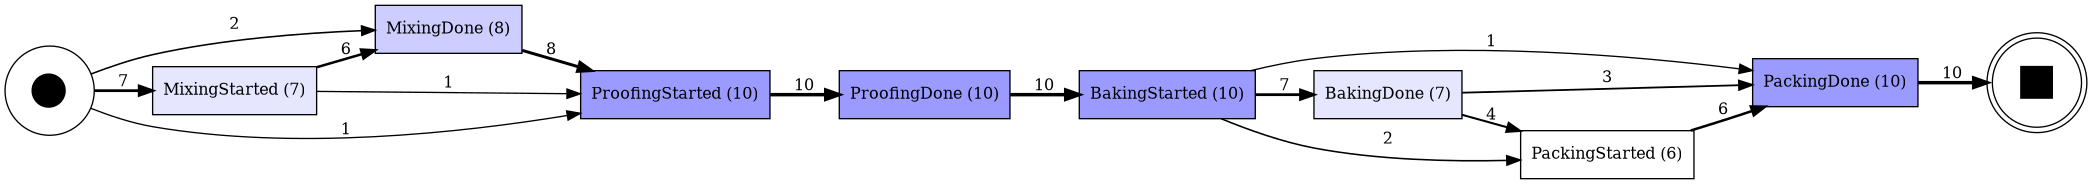

In [14]:
dirty_png = f"{OUT}/process_map_dirty.png"
pm4py.save_vis_dfg(dfg_d, start_d, end_d, dirty_png)
display(Image(dirty_png))

Сравните с картой из раздела (b). Вместо аккуратной цепочки — «спагетти».

In [15]:
sw_d = mining.service_and_waiting(dirty)
st_d, wait_d = mining.bottleneck(dirty)
params_d, arrival_d = mining.jaamsim_parameters(dirty)

cmp = pd.DataFrame({
    "чистый журнал": [len(dfg), len(start_acts), sw.loc["oven-1", "service_mean"],
                      wait, sw["total_mean"].sum(), arrival["mean"]],
    "грязный журнал": [len(dfg_d), len(start_d), sw_d.loc["oven-1", "service_mean"],
                       wait_d, sw_d["total_mean"].sum(), arrival_d["mean"]],
}, index=["рёбер в карте", "стартовых действий", "выпечка, мин",
          "ожидание печи, мин", "срок изготовления, мин", "интервал запуска, мин"])
cmp["ошибка, %"] = (100 * (cmp["грязный журнал"] / cmp["чистый журнал"] - 1)).round(0)
cmp.round(2)

,чистый журнал,грязный журнал,"ошибка, %"
рёбер в карте,7.00,11.00,57.0
стартовых действий,1.00,3.00,200.0
"выпечка, мин",25.67,22.93,-11.0
"ожидание печи, мин",106.49,44.54,-58.0
"срок изготовления, мин",189.41,126.61,-33.0
"интервал запуска, мин",12.80,16.39,28.0


### Почему качество данных — это не «гигиена», а деньгиФизика линии в обоих прогонах одинаковая. Отличается только то, что 15% отметок незаписалось. И вот что из этого вышло.**Карта процесса стала ложной.** Вместо 7 переходов — 11, вместо одного начала процесса — три(`MixingStarted`, `MixingDone`, `ProofingStarted`). Появились переходы, которых на линиифизически нет: `BakingStarted -> PackingDone` — это «поставили в печь и сразу упаковали»,такого не было ни разу. Он возник потому, что пропали `BakingDone` и `PackingStarted`, аprocess mining честно соединил то, что осталось. Алгоритм не ошибся — ему дали неверныеданные, и он не может об этом знать.**Числа сместились так, что решение меняется.** Ожидание перед печью упало со 106 до 44 минут— в 2.4 раза. Не потому, что печь стала быстрее: пропавшие `ProofingDone` выбросили из расчётаименно те партии, которые ждали дольше всех. Интервал запуска, наоборот, вырос с 12.8 до 16.4минуты — пропавшие `MixingStarted` сделали поток разреженнее, чем он был.Соберите это вместе и посмотрите глазами владельца: «партии ждут печь всего 44 минуты, азапускаем мы их раз в 16 минут» — это картина линии, которая **почти справляется**. Вывод:вторая печь не нужна, хватит организационных мер. По чистым данным вывод прямо противоположный.Ошибка стоимостью в печь — и ни один этап анализа при этом не был выполнен неправильно.**Практический вывод.** Прежде чем интерпретировать карту процесса, проверьте три вещи:сколько партий прошли полный маршрут (здесь: 1 из 10), сколько у процесса стартовых действий(должно быть одно) и нет ли на карте переходов, невозможных физически. Все три сигнала быливидны в этой тетради **до** того, как мы посчитали хоть одну длительность.

---## Итог* Узкое место линии — **печь**: 106.5 минуты ожидания при 25.7 минуты работы, 70% срока  изготовления партии, очередь до 9 партий.* Причина не в скорости печи, а в **арифметике**: запуск раз в 12.5 мин против 25 мин на  партию при вместимости 1.* Расстойка узким местом **не является** — её ускорение ничего не даст. Проверяем в JaamSim.* Параметры для симулятора — в разделе (d).* Тот же анализ на журнале с 15% пропусков даёт **противоположное управленческое решение**.Дальше: `docs/runbook-bakery-scenario.md`, шаги 4–6.